In [167]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [168]:
calories = pd.read_csv('calories.csv')
exercise = pd.read_csv('exercise.csv')

In [169]:
calories.head(2)

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0


In [170]:
exercise.head(2)

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3


In [171]:
df = exercise.merge(calories,on='User_ID')

In [172]:
df.head(3)

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0


Univariate Analysis

In [173]:
#sns.countplot(df['Gender'])

In [174]:
df.shape

(15000, 9)

In [175]:
#df['Gender'].value_counts()

In [176]:
#plt.hist(df['Age'],bins=20)

Bi or multi variate analysis

Scatterplot(Numerical to numerical)

In [177]:
df.head(1)

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0


In [178]:
#sns.scatterplot(x=df['Duration'],y=df['Calories'])

Bar Plot(Numerical - Categorical)

<Axes: xlabel='Age', ylabel='Duration'>

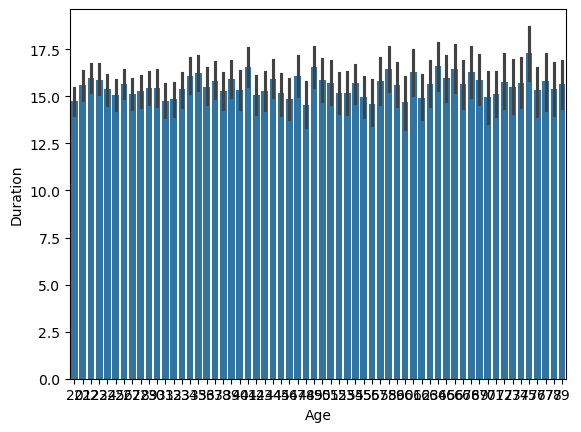

In [179]:
sns.barplot(x=df['Age'], y=df['Duration'])

Boxplot(numerical to categorical)

In [180]:
#sns.boxplot(x=df['Gender'],y=df['Age'])

In [181]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


Distplot(Numerical - Categorical)

In [182]:
# sns.distplot(df[df['Gender']=='Male']['Age'])

Lineplot(Numerical - Numerical)


In [183]:
#sns.lineplot(x=df['Age'],y=df['Calories'])

# Encoding

In [184]:
df['Gender'] = df['Gender'].map({'male':1,'female':0})


In [185]:
df.head(3)

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,1,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,0,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,1,69,179.0,79.0,5.0,88.0,38.7,26.0


Train test split

In [186]:
x = df.drop(['User_ID','Calories'],axis=1)
y = df['Calories']

In [187]:
x.shape

(15000, 7)

In [188]:
y.shape

(15000,)

In [189]:
from sklearn.model_selection import train_test_split

In [190]:
x_train, x_test, y_train,y_test = train_test_split(x , y, test_size=0.2, random_state=42) 

In [191]:
X_train.shape

(12000, 7)

In [192]:
x_test.shape

(3000, 7)

Training Model

In [193]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_squared_error

In [194]:
models = {
    'lr':LinearRegression(),
    'rd':Ridge(),
    'ls':Lasso(),
    'dtr':DecisionTreeRegressor(),
    'rfr':RandomForestRegressor()
}
    

In [195]:
for name, mod in models.items():
    mod.fit(x_train,y_train)
    y_pred = mod.predict(x_test)

    print(f"{name} MSE: {mean_squared_error(y_test,y_pred)}, Score: {r2_score(y_test,y_pred)}")
    

lr MSE: 131.99574575081692, Score: 0.9672937151257295
rd MSE: 131.99625903139327, Score: 0.9672935879435945
ls MSE: 143.82689461175073, Score: 0.9643621590908396
dtr MSE: 28.040666666666667, Score: 0.9930520031017076
rfr MSE: 7.107354866666666, Score: 0.9982389192041797


Selecting model

In [200]:
rfr = RandomForestRegressor()
rfr.fit(x_train,y_train)
y_pred = rfr.predict(x_test)

In [201]:
import pickle

pickle.dump(rfr,open('rfr.pkl','wb'))

In [202]:
x_train.to_csv('x_train.csv')